# TAS Evaluation Pipeline — plots

Visual companion to the headline metric tables. The tables themselves now live in
`greedy_metrics_table.md` (via `scripts/greedy_metrics_table.py`) and
`debug_search/search_metrics_table.md` (via `scripts/search_metrics_table.py`); this
notebook only renders the **plots** those scripts can't — target-ID bar charts,
PR curves, the unlearning-vs-search scatter, and Beta posterior trajectories.

It scores runs straight off the **seeded** results trees

    debug_search/{smart,smart_fast,random}_search/seed<S>/<METHOD>/<DATASET>/<MODEL>/{raw_result.json, forget_all_qs.csv, beta_mean_trace.csv}

reusing the scoring functions from `scripts/greedy_metrics_table.py`, so every number
here stays in lockstep with the markdown tables.

In [1]:
from __future__ import annotations
import json, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.').resolve()

# Reuse the scoring + dataset definitions from the metrics-table scripts so the
# notebook's numbers stay in lockstep with greedy_metrics_table.md /
# search_metrics_table.md (same normalize / TRUE_TARGET / parse helpers).
sys.path.insert(0, str(ROOT / 'scripts'))
import greedy_metrics_table as g

REFUSAL_THRESHOLD = g.REFUSAL_THRESHOLD     # 0.5  (cliff.refusal_threshold)
TOPK_VALUES = (1, 3, 5, 10)

PLOT_DIR = ROOT / 'plans&notebooks' / 'eval_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

shorten_model = {
    'llama2-7b-chat': 'llama2',
    'llama3-8b-instruct': 'llama3',
    'gemma-7b-it': 'gemma'
}

## Ground truth: forget set + true target per dataset

* DUSK forget edge: `Roland_Lancaster_personal` → target = `Roland Lancaster` (one entity).
* PISTOL forget edge: `A_B` → target = `(Wnzatj SAS, Jzrcws SA)` (ordered tuple, slot0 / slot1).
* TOFU forget edge: `author_1_personal` → target = `Jaime Vasquez` (one entity).

These splits come straight from `scripts/greedy_metrics_table.py` (`g.load_dataset_split`,
`g.TRUE_TARGET`, `g.normalize`), so the forget sets match the markdown tables exactly.

In [2]:
# Build the forget-prompt sets the scorer expects (one set of normalized forget
# prompts per dataset) and re-export the shared helpers under short names.
g.FORGET_SETS = {n: g.load_dataset_split(n) for n in g.DATASET_FILES}

FORGET_SETS      = g.FORGET_SETS        # {dataset: set(normalized forget prompts)}
TRUE_TARGET      = g.TRUE_TARGET
normalize        = g.normalize
is_date_template = g.is_date_template

for n, fset in FORGET_SETS.items():
    print(f'{n}: |F|={len(fset)}  target={TRUE_TARGET[n]}  (date templates excluded)')

dusk: |F|=8  target=('Roland Lancaster',)  (date templates excluded)
pistol: |F|=17  target=('Wnzatj SAS', 'Jzrcws SA')  (date templates excluded)
tofu: |F|=7  target=('Jaime Vasquez',)  (date templates excluded)


## Run discovery over the seeded results trees

Each `(search_mode, seed, method, dataset, model)` leaf is one run. Posterior parsing
(`g.parse_beta`, `g.slot_posterior`) and history parsing (`g.parse_history_item`) are
imported so the per-run scoring matches the markdown tables.

In [3]:
# Seeded search-mode roots:
#   debug_search/<mode>_search/seed<S>/<METHOD>/<DATASET>/<MODEL>/raw_result.json
# The old budget-sweep / multi-seed `*_iteration` dirs now live under each tree's
# `archive/` subfolder and are skipped here (the budget-sweep cell reads them directly).
SEARCH_ROOTS = {
    'smart':      ROOT / 'debug_search' / 'smart_search',
    'smart_fast': ROOT / 'debug_search' / 'smart_fast_search',
    'random':     ROOT / 'debug_search' / 'random_search',
}

def list_runs():
    rows = []
    for mode, root in SEARCH_ROOTS.items():
        if not root.exists():
            continue
        for raw_path in sorted(root.rglob('raw_result.json')):
            rel = raw_path.relative_to(root).parts
            # seed<S>/<method>/<dataset>/<model>/raw_result.json  -> len 5
            if len(rel) != 5 or not rel[0].startswith('seed'):
                continue                       # skip archive/ and stray files
            seed, method, dataset, model = rel[:4]
            if dataset not in TRUE_TARGET:
                continue
            rows.append({
                'search_mode': mode, 'seed': seed, 'method': method,
                'dataset': dataset, 'model': model, 'modelsf': shorten_model[model], 'path': raw_path.parent,
            })
    return pd.DataFrame(rows)

RUNS = list_runs()
print(f'discovered {len(RUNS)} seeded runs')
print(RUNS.groupby(['search_mode', 'dataset']).size().unstack(fill_value=0))
RUNS.head()

discovered 201 seeded runs
dataset      dusk  pistol  tofu
search_mode                    
random         27      27    21
smart          27      27    18
smart_fast     27      27     0


,search_mode,seed,method,dataset,model,modelsf,path
0,smart,seed0,DPO,dusk,gemma-7b-it,gemma,/nfs-share/ahta3/workspace/LUNAR/debug_search/smart_search/seed0/DPO/dusk/gemma-7b-it
1,smart,seed0,DPO,dusk,llama2-7b-chat,llama2,/nfs-share/ahta3/workspace/LUNAR/debug_search/smart_search/seed0/DPO/dusk/llama2-7b-chat
2,smart,seed0,DPO,dusk,llama3-8b-instruct,llama3,/nfs-share/ahta3/workspace/LUNAR/debug_search/smart_search/seed0/DPO/dusk/llama3-8b-instruct
3,smart,seed0,DPO,pistol,gemma-7b-it,gemma,/nfs-share/ahta3/workspace/LUNAR/debug_search/smart_search/seed0/DPO/pistol/gemma-7b-it
4,smart,seed0,DPO,pistol,llama2-7b-chat,llama2,/nfs-share/ahta3/workspace/LUNAR/debug_search/smart_search/seed0/DPO/pistol/llama2-7b-chat


## Compute per-run metrics (for the plots)

This builds the per-run `df` the plots below consume. It scores the same Q1/Q2/Q3
quantities as the markdown tables, plus a few plot-only extras (`posterior_margin`,
`slot_ranks`, `prompt_fp_rate`, `query_precision/recall`) that the tables don't report.

For PISTOL the target is an ordered 2-tuple; entity metrics are evaluated **slot-wise**:
exact_match needs all slots correct, `posterior_margin` is the **min** top1-top2 gap.

In [4]:
def metrics_for_run(run):
    """Rich per-run scoring. Shares definitions with scripts/greedy_metrics_table.py
    (g.slot_posterior / g.parse_history_item) and adds the plot-only extras."""
    p = run['path']
    raw = json.load(open(p / 'raw_result.json'))
    forget_set = FORGET_SETS[run['dataset']]
    true_target = TRUE_TARGET[run['dataset']]
    n_slots = len(true_target)

    if 'ranked_slots' in raw:
        ranked_slots = raw['ranked_slots']
        ent_slots = raw['ent_slots']
    else:
        ranked_slots, ent_slots = [], []
        for s in range(1, n_slots + 1):
            ranked_slots.append(raw.get(f'ranked_slot{s}', []))
            ent_slots.append(raw.get(f'ent_slot{s}', {}))
    top1_pred = tuple(rs[0] if rs else '' for rs in ranked_slots)
    exact_match = int(top1_pred == true_target)
    slot_ranks, slot_gaps = [], []
    for s, rs in enumerate(ranked_slots):
        try: slot_ranks.append(rs.index(true_target[s]) + 1)
        except ValueError: slot_ranks.append(len(rs) + 1)
        post = g.slot_posterior(ent_slots[s]) if ent_slots[s] else []
        slot_gaps.append(post[0][1] - post[1][1] if len(post) >= 2 else 0.0)
    avg_rank = float(np.mean(slot_ranks))
    mrr = float(np.mean([1.0 / r for r in slot_ranks]))
    posterior_margin = float(min(slot_gaps)) if slot_gaps else 0.0
    topk_hits = {k: int(all(slot_ranks[s] <= k for s in range(n_slots))) for k in TOPK_VALUES}

    fq_path = p / 'forget_all_qs.csv'
    if fq_path.exists():
        fq = pd.read_csv(fq_path)
        norm_series = (fq.loc[fq['refusal_score'] >= REFUSAL_THRESHOLD, 'edited_prompt']
                         .map(lambda t: normalize(t, run['dataset'])))
        discovered_norm = {q for q in norm_series if not is_date_template(q)}
    else:
        discovered_norm = set()
    n_disc = len(discovered_norm)
    tp = len(discovered_norm & forget_set)
    fp = len(discovered_norm - forget_set)
    recall = tp / len(forget_set) if forget_set else 0.0
    precision = tp / n_disc if n_disc else 0.0
    fp_rate_prompt = fp / n_disc if n_disc else 0.0

    # ---- Q3 query-level confusion matrix ----
    parsed = [g.parse_history_item(h) for h in raw.get('history', [])]
    queries = len(parsed)
    q_tp = q_fp = q_fn = q_tn = 0
    target_first = None
    for i, (ents, y) in enumerate(parsed):
        is_gt = (ents == true_target)
        is_refusal = (y >= REFUSAL_THRESHOLD)
        if is_gt and is_refusal:         q_tp += 1
        elif (not is_gt) and is_refusal: q_fp += 1
        elif is_gt and (not is_refusal): q_fn += 1
        else:                            q_tn += 1
        if is_gt and target_first is None:
            target_first = i
    target_probes = q_tp + q_fn
    refusals      = q_tp + q_fp
    query_precision = q_tp / refusals      if refusals      else 0.0
    query_recall    = q_tp / target_probes if target_probes else 0.0

    return {
        **{k: run[k] for k in ('search_mode', 'seed', 'method', 'dataset', 'model')},
        'modelsf': run.get('modelsf', shorten_model.get(run['model'], run['model'])),
        'top1_pred': '|'.join(top1_pred),
        # Q1 entity-level
        'exact_match': exact_match, 'avg_rank': avg_rank, 'mrr': mrr,
        **{f'top{k}_hit': topk_hits[k] for k in TOPK_VALUES},
        'posterior_margin': posterior_margin,
        'slot_ranks': tuple(slot_ranks),         # used by the PR curve below
        # Q2 prompt-level
        'discovered': n_disc, 'recall': recall, 'precision': precision,
        'prompt_fp_rate': fp_rate_prompt,
        # Q3 query-level
        'queries': queries,
        'query_precision': query_precision, 'query_recall': query_recall,
        'target_first_occurrence': target_first if target_first is not None else -1,
    }

df = pd.DataFrame([metrics_for_run(r) for _, r in RUNS.iterrows()])
print(f'scored {len(df)} runs')
print(df.groupby(['search_mode', 'dataset'])['exact_match'].mean().round(3))

scored 201 runs
search_mode  dataset
random       dusk       0.852
             pistol     0.296
             tofu       0.238
smart        dusk       1.000
             pistol     1.000
             tofu       0.333
smart_fast   dusk       1.000
             pistol     1.000
Name: exact_match, dtype: float64


## Plots

Three figures (one per question) for smart search, plus a search-mode comparison.
Bars are **averaged over seeds** (each method/model/dataset cell pools seeds 0/1/2).

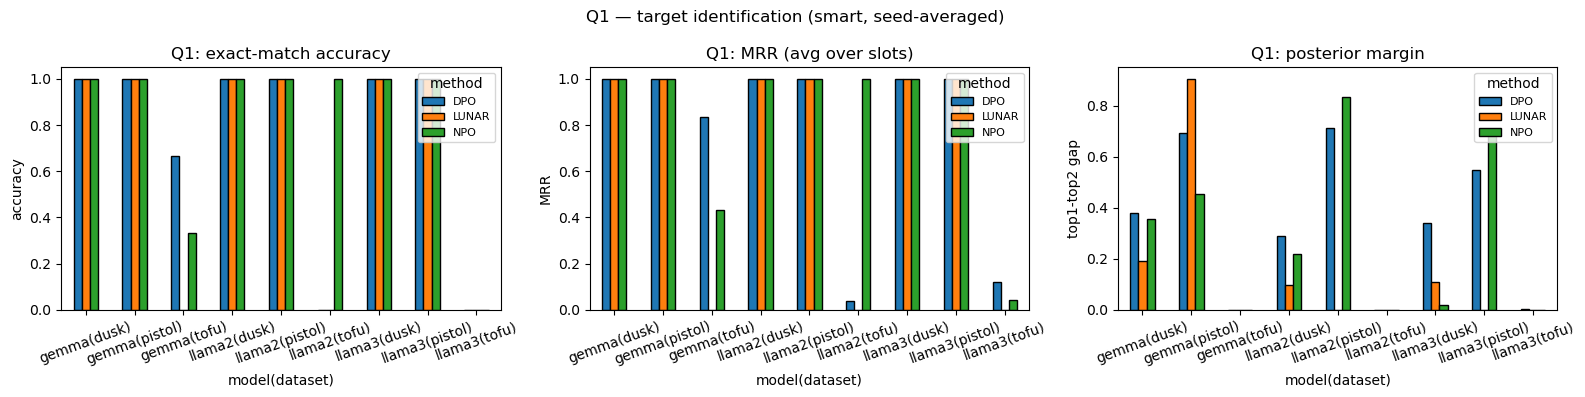

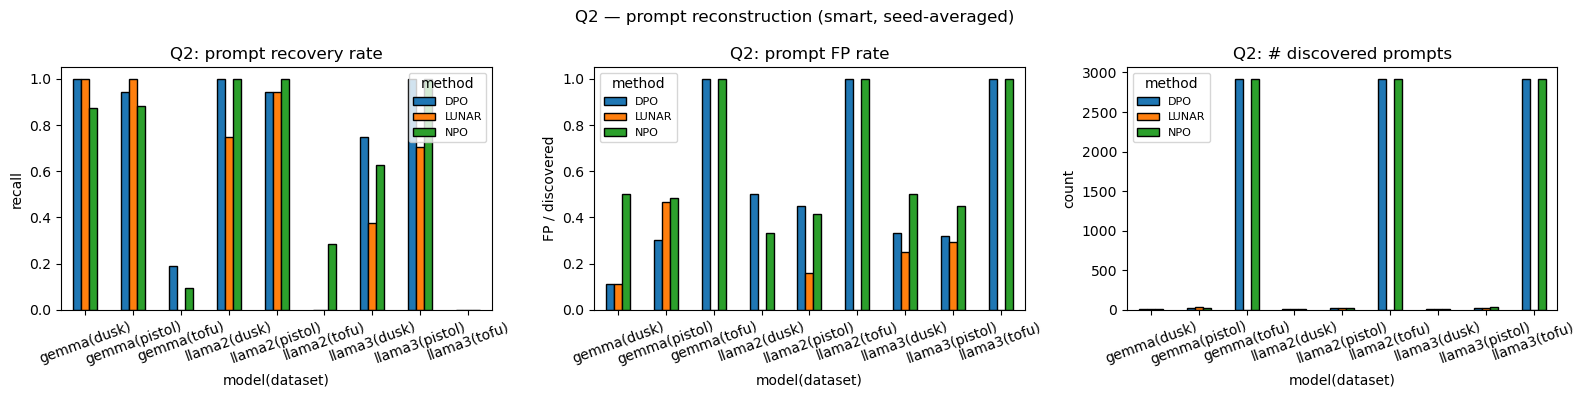

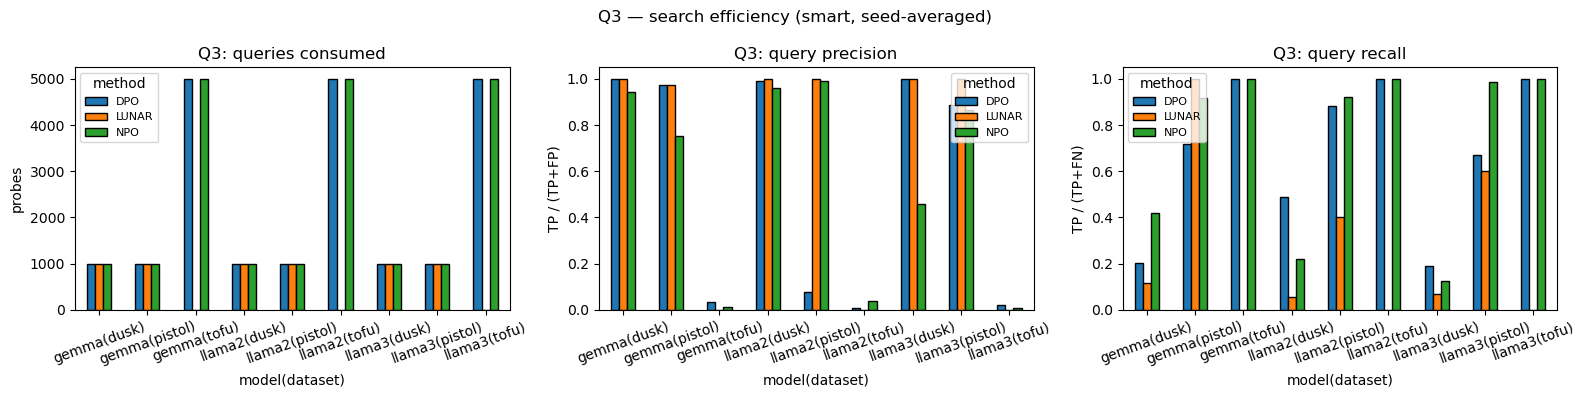

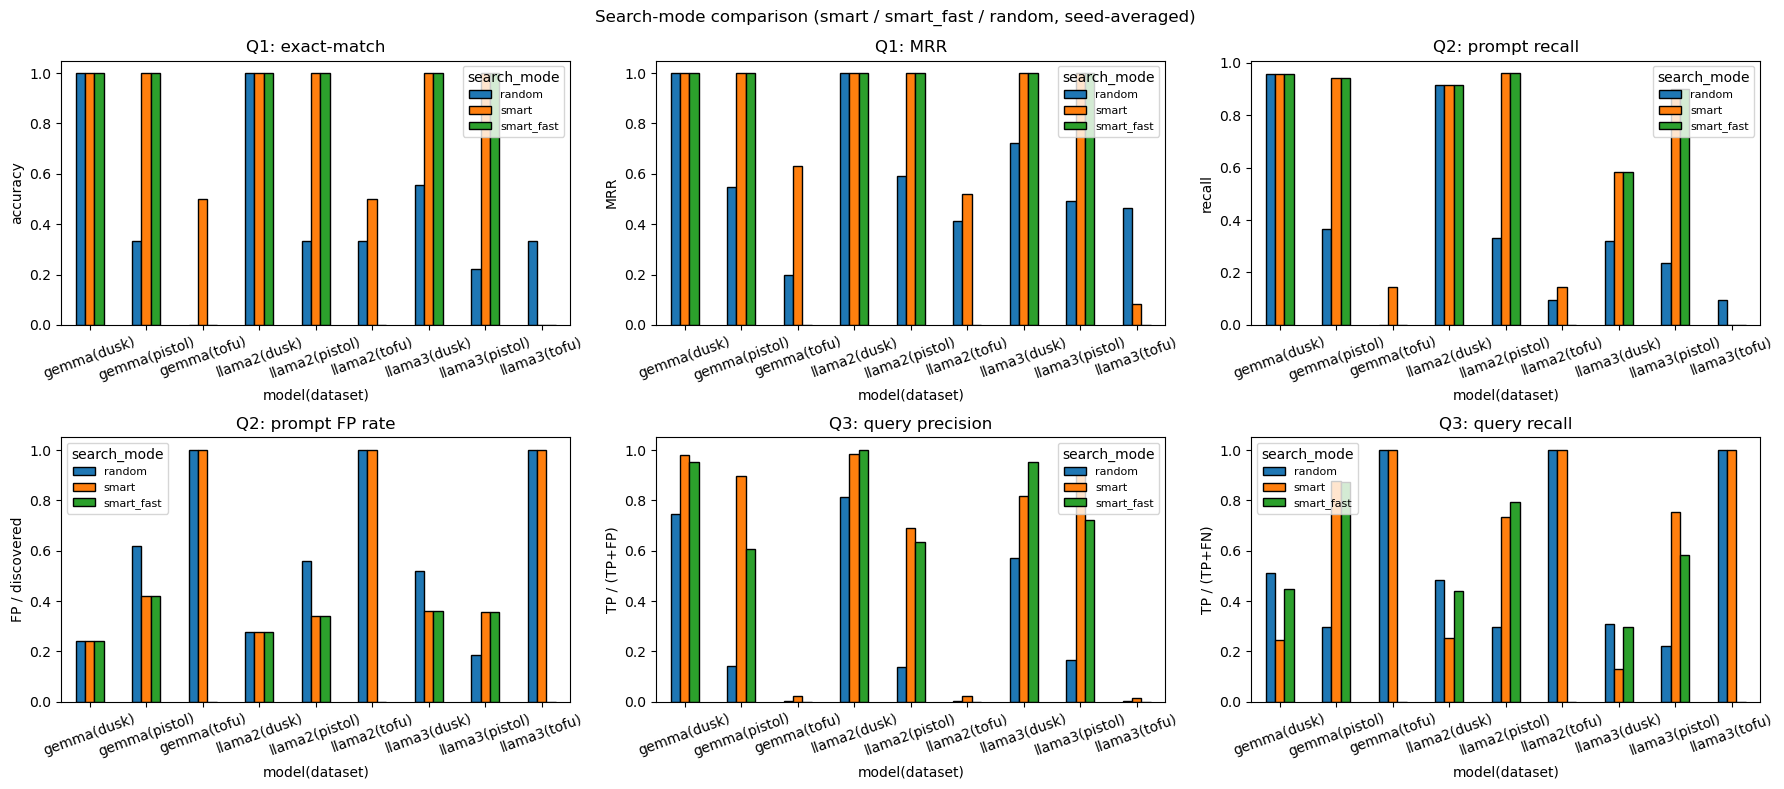

In [5]:
def grouped_bar(ax, sub, x_col, y_col, title, ylabel, hue='method'):
    # aggfunc='mean' collapses the 3 seeds in each (x_col, hue) cell.
    pivot = sub.pivot_table(index=x_col, columns=hue, values=y_col, aggfunc='mean')
    pivot.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel(x_col)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title=hue, fontsize=8)

# ---- Smart-search target/prompt/query bars (seed-averaged) ----
smart = df[df['search_mode'] == 'smart'].copy()
smart['model(dataset)'] = smart['modelsf'] + '(' + smart['dataset'] + ')'

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
grouped_bar(axes[0], smart, 'model(dataset)', 'exact_match', 'Q1: exact-match accuracy', 'accuracy')
grouped_bar(axes[1], smart, 'model(dataset)', 'mrr', 'Q1: MRR (avg over slots)', 'MRR')
grouped_bar(axes[2], smart, 'model(dataset)', 'posterior_margin', 'Q1: posterior margin', 'top1-top2 gap')
fig.suptitle('Q1 — target identification (smart, seed-averaged)'); fig.tight_layout()
fig.savefig(PLOT_DIR / 'q1_target.png', dpi=130); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
grouped_bar(axes[0], smart, 'model(dataset)', 'recall', 'Q2: prompt recovery rate', 'recall')
grouped_bar(axes[1], smart, 'model(dataset)', 'prompt_fp_rate', 'Q2: prompt FP rate', 'FP / discovered')
grouped_bar(axes[2], smart, 'model(dataset)', 'discovered', 'Q2: # discovered prompts', 'count')
fig.suptitle('Q2 — prompt reconstruction (smart, seed-averaged)'); fig.tight_layout()
fig.savefig(PLOT_DIR / 'q2_prompt.png', dpi=130); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
grouped_bar(axes[0], smart, 'model(dataset)', 'queries', 'Q3: queries consumed', 'probes')
grouped_bar(axes[1], smart, 'model(dataset)', 'query_precision', 'Q3: query precision', 'TP / (TP+FP)')
grouped_bar(axes[2], smart, 'model(dataset)', 'query_recall', 'Q3: query recall', 'TP / (TP+FN)')
fig.suptitle('Q3 — search efficiency (smart, seed-averaged)'); fig.tight_layout()
fig.savefig(PLOT_DIR / 'q3_query.png', dpi=130); plt.show()

# ---- Search-mode comparison (smart vs smart_fast vs random, seed-averaged) ----
allm = df.copy()
allm['model(dataset)'] = allm['modelsf'] + '(' + allm['dataset'] + ')'

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
grouped_bar(axes[0,0], allm, 'model(dataset)', 'exact_match', 'Q1: exact-match', 'accuracy', hue='search_mode')
grouped_bar(axes[0,1], allm, 'model(dataset)', 'mrr', 'Q1: MRR', 'MRR', hue='search_mode')
grouped_bar(axes[0,2], allm, 'model(dataset)', 'recall', 'Q2: prompt recall', 'recall', hue='search_mode')
grouped_bar(axes[1,0], allm, 'model(dataset)', 'prompt_fp_rate', 'Q2: prompt FP rate', 'FP / discovered', hue='search_mode')
grouped_bar(axes[1,1], allm, 'model(dataset)', 'query_precision', 'Q3: query precision', 'TP / (TP+FP)', hue='search_mode')
grouped_bar(axes[1,2], allm, 'model(dataset)', 'query_recall',    'Q3: query recall',    'TP / (TP+FN)', hue='search_mode')
fig.suptitle('Search-mode comparison (smart / smart_fast / random, seed-averaged)')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'search_mode_compare.png', dpi=130); plt.show()

### Entity-level precision-recall curve

For each run we have a ranked candidate list per slot, with the ground-truth target's
rank. Sweeping a rank-cutoff `k` (predict positive for the top-k entities of every slot):

* **recall@k** = `1 if GT rank ≤ k for every slot else 0` — averaged across runs in the
  same (search_mode, dataset) group (all seeds pooled).
* **precision@k** = (recall@k) / k — fraction of the top-k flagged entities that are GT.

Each slot has exactly one ground-truth, so the per-run curve is a step function; pooling
runs gives a smoother trace.

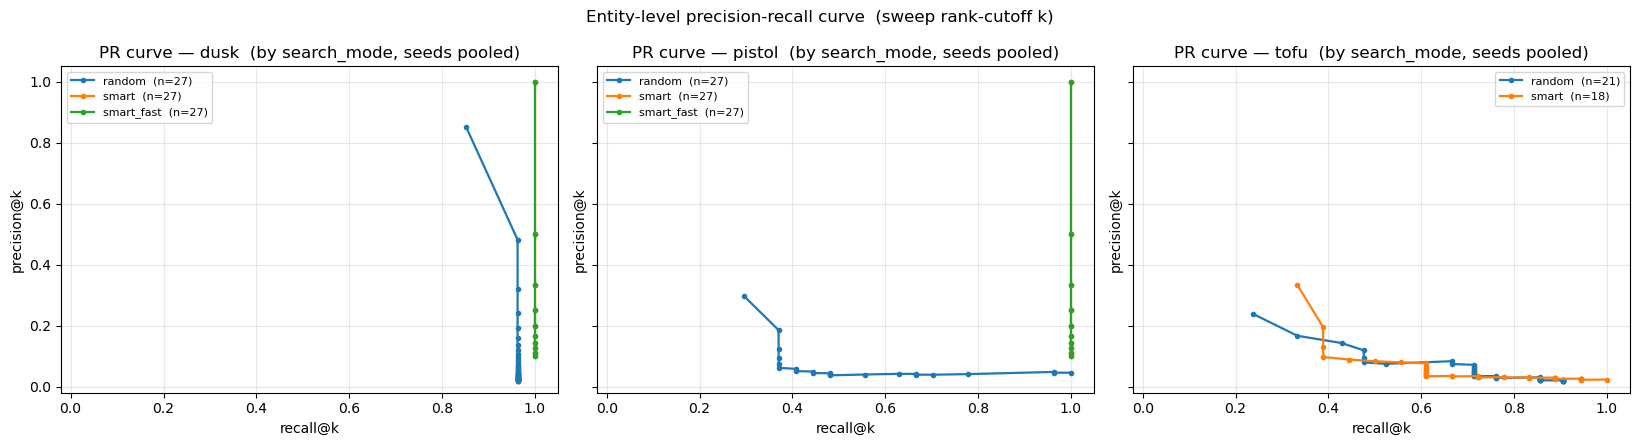

In [6]:
def pr_curve_for_group(group_df, max_k=50):
    """Macro-averaged precision@k / recall@k over a group of runs (same dataset +
    search-mode), sweeping rank-cutoff k from 1 to max_k."""
    ks = np.arange(1, max_k + 1)
    if len(group_df) == 0:
        return ks, np.zeros_like(ks, dtype=float), np.zeros_like(ks, dtype=float)
    joint = group_df['slot_ranks'].apply(lambda t: max(t) if t else 9999).values
    recall_at_k    = np.array([(joint <= k).mean() for k in ks])
    precision_at_k = recall_at_k / ks
    return ks, precision_at_k, recall_at_k

# Pool all seeds; one curve per search_mode within each dataset panel.
datasets = sorted(df['dataset'].unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(5.5 * len(datasets), 4.5), sharey=True)
if len(datasets) == 1: axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df['dataset'] == ds]
    for mode in sorted(sub['search_mode'].unique()):
        gdf = sub[sub['search_mode'] == mode]
        max_k = min(50, max(int(gdf['slot_ranks'].apply(max).max()), 10))
        ks, prec, rec = pr_curve_for_group(gdf, max_k=max_k)
        ax.plot(rec, prec, marker='o', markersize=3, linewidth=1.6,
                label=f'{mode}  (n={len(gdf)})')
    ax.set_xlabel('recall@k'); ax.set_ylabel('precision@k')
    ax.set_title(f'PR curve — {ds}  (by search_mode, seeds pooled)')
    ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Entity-level precision-recall curve  (sweep rank-cutoff k)')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'pr_curve_entity.png', dpi=130)
plt.show()

## How does unlearning quality affect search performance?

We pull `forget.*` evaluation stats from `unlearn_results/completions/<method>/<model>/<dataset>/forget_*eval*.json` (or `forget_<step>.json` for LUNAR). The relevant signal is *how forgotten the forget set is* — we use:

* `forget.probs` — sequence probability the unlearned model assigns to the ground-truth answer (lower = more forgotten).
* `forget.rouge1_recall` — string overlap with the gt answer (lower = more forgotten).
* `forget.perplexity` — perplexity of gt answer (higher = more forgotten).

We then merge with the search-side metrics and look at correlations against `recall`, `mrr`, and `queries`.

In [7]:
DATASET_FOLDER = {'dusk': 'dusk', 'pistol': 'pistol_sample1', 'tofu': 'tofu'}
METHOD_FOLDER  = {'LUNAR': 'lunar', 'DPO': 'dpo', 'NPO': 'npo'}
UNLEARN_ROOT   = ROOT / 'unlearn_results' / 'completions'

def find_forget_eval(method: str, model: str, dataset: str):
    """Pick the most-recent / largest-step forget*.json under the folder."""
    if dataset not in DATASET_FOLDER: return None
    folder = UNLEARN_ROOT / METHOD_FOLDER[method] / model / DATASET_FOLDER[dataset]
    if not folder.exists(): return None
    cands = list(folder.glob('forget*.json'))
    if not cands: return None
    def step(p):
        m = re.search(r"_(\d+)\.json$", p.name)
        return int(m.group(1)) if m else -1
    cands.sort(key=lambda p: (step(p), p.stat().st_mtime))
    return cands[-1]

unl_rows = []
for (method, dataset, model), _ in df.groupby(['method', 'dataset', 'model']):
    p = find_forget_eval(method, model, dataset)
    if not p: continue
    blob = json.load(open(p))
    f = blob.get('forget', {})
    unl_rows.append({
        'method': method, 'dataset': dataset, 'model': model,
        'forget_probs': f.get('probs'),
        'forget_rouge1': f.get('rouge1_recall'),
        'forget_perplexity': f.get('perplexity'),
        'forget_mrr': f.get('mrr'),
        'forget_hit_rate': f.get('hit_rate'),
        'eval_file': str(p.relative_to(ROOT)),
    })
U = pd.DataFrame(unl_rows)
print(f'matched {len(U)} unlearn-eval files')

matched 23 unlearn-eval files


In [8]:
# Build M: smart-search metrics averaged over seeds, merged with the unlearning
# eval, for the scatter below. (The merged + correlation TABLES live in the
# markdown reports now; here we keep only the data the scatter needs.)
search_avg = (df[df['search_mode'] == 'smart']
                .groupby(['method', 'dataset', 'model'])
                [['exact_match', 'mrr', 'recall', 'prompt_fp_rate', 'queries',
                  'posterior_margin', 'target_first_occurrence']]
                .mean().reset_index())
M = (search_avg.merge(U, on=['method', 'dataset', 'model'], how='inner')
     if not U.empty else pd.DataFrame())
print(f'merged {len(M)} (method, dataset, model) cells with unlearning eval')

merged 23 (method, dataset, model) cells with unlearning eval


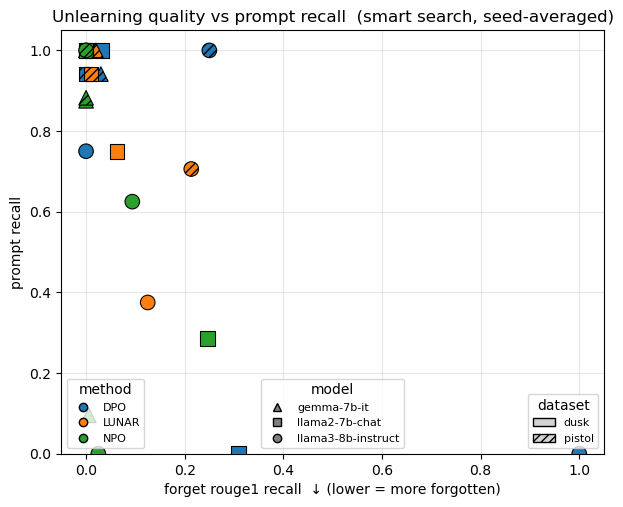

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

if len(M) >= 3:
    # Smart-search only (M is filtered to search_mode='smart', seed-averaged, by
    # the merged cell above). Single-panel: forget rouge1 vs prompt recall.
    # Three encodings (no text labels): colour = method, marker shape = model,
    # fill pattern = dataset.
    METHOD_COLORS = {m: c for m, c in zip(sorted(M['method'].unique()),
                                          plt.cm.tab10.colors)}
    MODEL_MARKERS = {
        'gemma-7b-it':        '^',   # triangle
        'llama2-7b-chat':     's',   # square
        'llama3-8b-instruct': 'o',   # circle
    }
    DATASET_HATCH = {
        'dusk':   '',       # solid fill
        'pistol': '////',   # diagonal stripes
        # 'tofu':   '....',   # dotted
    }
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for (method, model, dataset), sub in M.groupby(['method', 'model', 'dataset']):
        ax.scatter(sub['forget_rouge1'], sub['recall'],
                   color=METHOD_COLORS[method],
                   marker=MODEL_MARKERS.get(model, 'D'),
                   hatch=DATASET_HATCH.get(dataset, ''),
                   s=110, edgecolor='black', linewidth=0.8, zorder=3)
    ax.set_xlabel('forget rouge1 recall  ↓ (lower = more forgotten)')
    ax.set_ylabel('prompt recall')
    ax.set_title('Unlearning quality vs prompt recall  (smart search, seed-averaged)')
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    # Three legends: colour = method, marker shape = model, fill pattern = dataset.
    method_handles = [Line2D([0], [0], marker='o', linestyle='', color=c,
                             markeredgecolor='black', label=m)
                      for m, c in METHOD_COLORS.items()]
    model_handles = [Line2D([0], [0], marker=mk, linestyle='', color='gray',
                            markeredgecolor='black', label=ml)
                     for ml, mk in MODEL_MARKERS.items()]
    dataset_handles = [Patch(facecolor='lightgray', edgecolor='black', hatch=h, label=d)
                       for d, h in DATASET_HATCH.items()]
    leg1 = ax.legend(handles=method_handles, title='method', fontsize=8, loc='lower left')
    leg2 = ax.legend(handles=model_handles, title='model', fontsize=8, loc='lower center')
    ax.add_artist(leg1); ax.add_artist(leg2)
    ax.legend(handles=dataset_handles, title='dataset', fontsize=8, loc='lower right')

    fig.savefig(PLOT_DIR / 'unlearn_vs_recall.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('not enough merged rows for the scatter')

## Reading the plots

* **Q1 — exact-match / MRR / margin.** Higher is better. A run with `top1_hit==1` but a
  small `posterior_margin` was a lucky stop; a wide margin is a confident stop.
* **Q2 — recall / prompt_fp_rate.** `recall = |D ∩ F| / |F|`; `prompt_fp_rate = |D \ F| / |D|`.
  Over-searching is fine — `discovered` is shown for context, not scored.
* **Q3 — queries / query precision / recall.** Fewer queries is better; `query_recall` is
  how often the true target probe was flagged refusal-like, `query_precision` how clean
  the flagged probes are.
* **Unlearning sensitivity (scatter).** A negative trend between `forget_rouge1` and prompt
  `recall` is the expected finding: more-forgotten targets give cleaner refusal signals.

The headline numbers behind these plots are tabulated in `greedy_metrics_table.md` and
`debug_search/search_metrics_table.md`.

## Budget sweep — how does attack performance change with budget?

The budget-sweep runs live under the `archive/` subtree
(`debug_search/smart_search/archive/DPO/<dataset>/llama2-7b-chat/<N>_iteration/`). They
share method/model/dataset and differ only in the `smart_search.budget` cap, so we can
plot search-quality metrics directly against the probe budget.

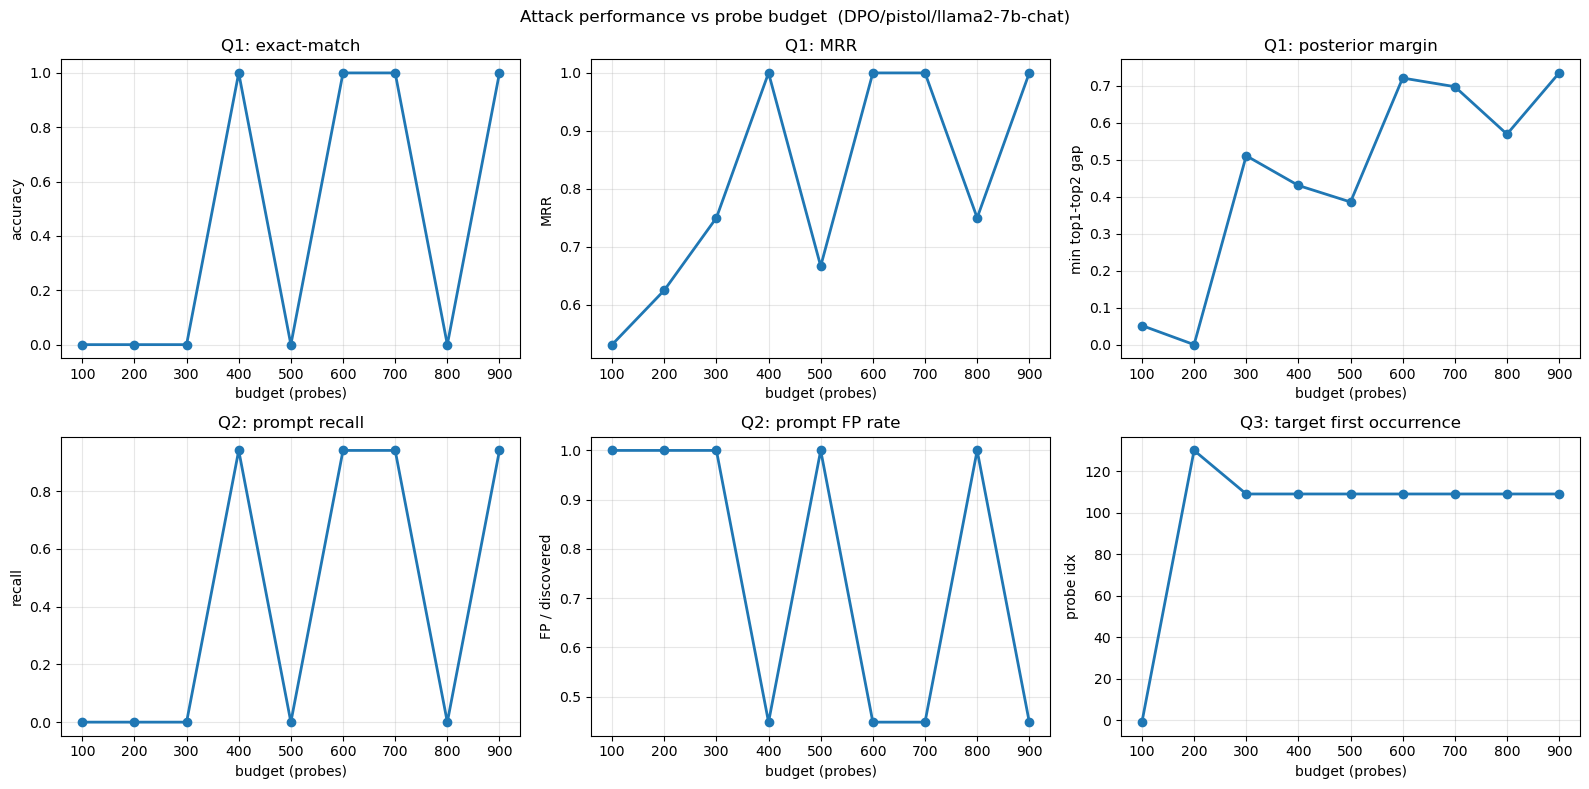

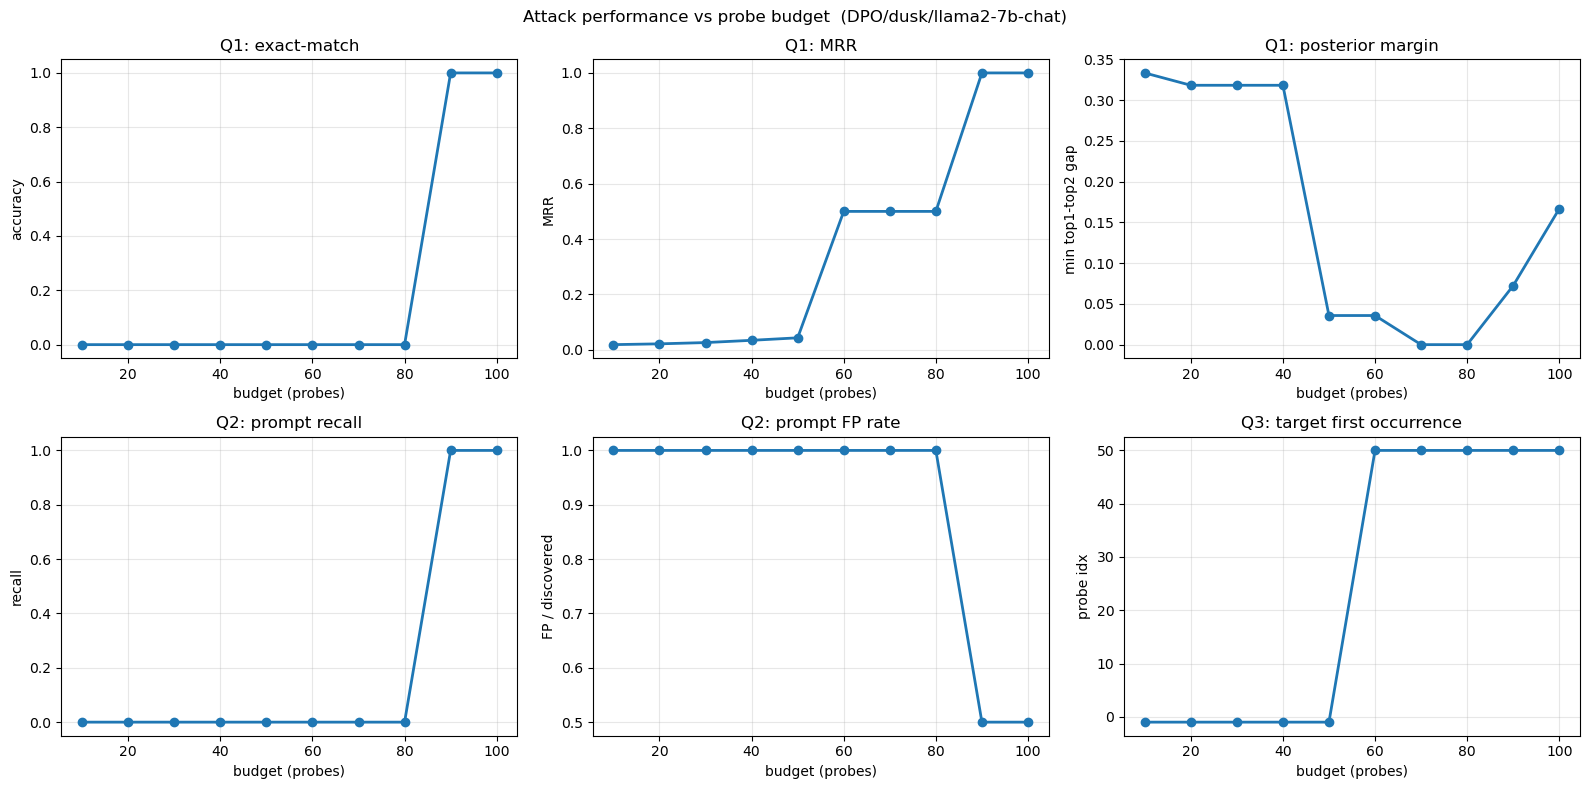

In [10]:
BUDGET_RUN_RE = re.compile(r'^(\d+)_iteration$')

def sweep_budget(run_dir, search_mode, method, dataset, model, label,
                 min_budget=None, max_budget=None):
    """Discover every <N>_iteration subdir of run_dir, score it with metrics_for_run,
    then render a metric-vs-budget plot. `min_budget` / `max_budget` (inclusive)
    restrict which budgets enter the sweep."""
    rows = []
    for sub in sorted(run_dir.iterdir()):
        if not sub.is_dir(): continue
        m = BUDGET_RUN_RE.match(sub.name)
        if not m: continue
        budget = int(m.group(1))
        if min_budget is not None and budget < min_budget: continue
        if max_budget is not None and budget > max_budget: continue
        rec = metrics_for_run({
            'search_mode': search_mode, 'seed': sub.name, 'method': method,
            'dataset': dataset, 'model': model, 'path': sub,
        })
        rec['budget'] = budget
        rows.append(rec)
    bdf = pd.DataFrame(rows).sort_values('budget').reset_index(drop=True)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    plot_specs = [
        ('exact_match',             'Q1: exact-match',            'accuracy'),
        ('mrr',                     'Q1: MRR',                    'MRR'),
        ('posterior_margin',        'Q1: posterior margin',       'min top1-top2 gap'),
        ('recall',                  'Q2: prompt recall',          'recall'),
        ('prompt_fp_rate',          'Q2: prompt FP rate',         'FP / discovered'),
        ('target_first_occurrence', 'Q3: target first occurrence','probe idx'),
    ]
    for ax, (col, title, ylab) in zip(axes.ravel(), plot_specs):
        ax.plot(bdf['budget'], bdf[col], marker='o', linewidth=2)
        ax.set_xlabel('budget (probes)'); ax.set_ylabel(ylab); ax.set_title(title)
        ax.grid(alpha=0.3)
    fig.suptitle(f'Attack performance vs probe budget  ({label})')
    fig.tight_layout()
    safe = label.replace('/', '_').replace(' ', '')
    fig.savefig(PLOT_DIR / f'budget_sweep_{safe}.png', dpi=130)
    plt.show()
    return bdf

ARCHIVE = ROOT / 'debug_search/smart_search/archive'

# (a) PISTOL sweep — 100..1000 in steps of 100
budget_df_pistol = sweep_budget(
    ARCHIVE / 'DPO/pistol/llama2-7b-chat',
    'smart', 'DPO', 'pistol', 'llama2-7b-chat',
    'DPO/pistol/llama2-7b-chat',
    min_budget=100, max_budget=1000)

# (b) DUSK sweep — 10..100 (keep the same minimum story as PISTOL).
budget_df_dusk = sweep_budget(
    ARCHIVE / 'DPO/dusk/llama2-7b-chat',
    'smart', 'DPO', 'dusk', 'llama2-7b-chat',
    'DPO/dusk/llama2-7b-chat',
    min_budget=10, max_budget=100)

## Beta-mean trajectory — how does each entity's posterior evolve?

Each smart-search run dumps `beta_mean_trace.csv` with one row per `(step, slot, entity)`
— a snapshot of every entity's Beta(a,b) mean after every probe. We plot each slot in its
own panel; every line is one candidate entity and the **ground-truth entity for that slot
is highlighted** (red, thick), with the others drawn translucent.

Traces are read from the seeded tree (`seed0/...`); the long TOFU runs only exist under
`archive/.../30000_iteration/` and are read from there, sampled every 100 steps.

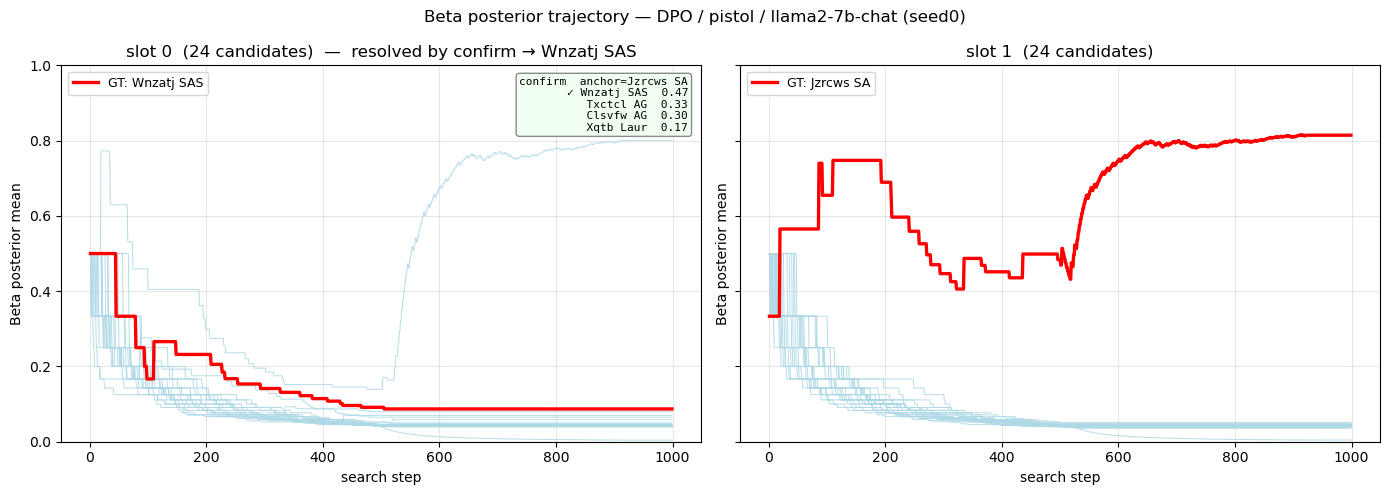

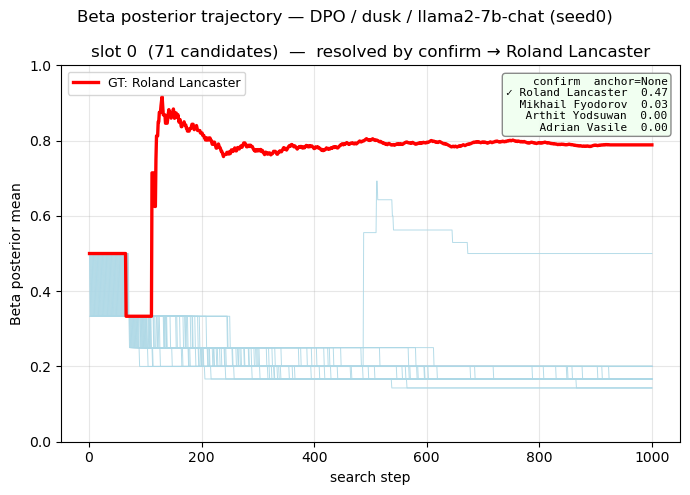

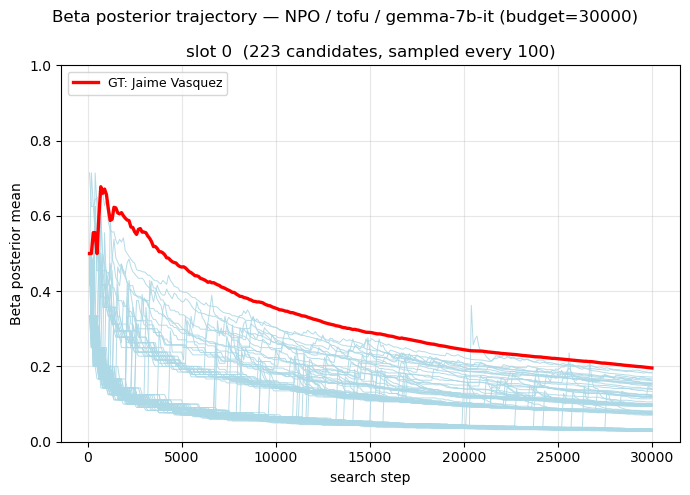

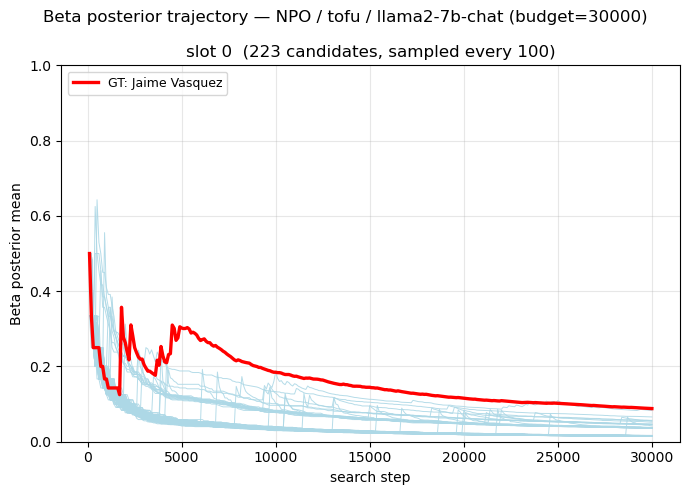

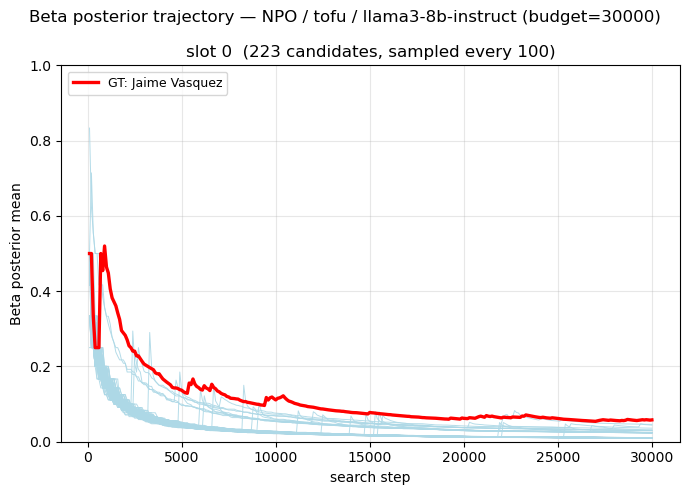

In [11]:
def load_beta_trace(trace_path, every=1, chunk=500_000):
    """Stream-load a trace CSV, optionally keeping only rows whose step is a
    multiple of `every` (the 30000-probe TOFU traces are ~6.7M rows)."""
    if every <= 1:
        return pd.read_csv(trace_path)
    keep = []
    for c in pd.read_csv(trace_path, chunksize=chunk):
        keep.append(c[c['step'] % every == 0])
    return pd.concat(keep, ignore_index=True) if keep else pd.DataFrame()

def load_confirm(trace_path):
    """Return {slot_idx: confirm_dict} for the run owning this trace, or {}.

    The pair-attack runs a post-search *confirm* phase: once one slot is locked,
    the finalists for the other slot are re-probed against that anchor and the
    winner is written into `ranked_slots` — but NOT back into the Beta posteriors.
    So the confirm decision is invisible in `beta_mean_trace.csv`; we surface it
    here so a panel whose trajectory disagrees with the final answer is explained."""
    rr = Path(trace_path).parent / 'raw_result.json'
    if not rr.exists():
        return {}
    conf = json.load(open(rr)).get('confirm')
    if not conf:
        return {}
    confs = conf if isinstance(conf, list) else [conf]
    return {c['slot']: c for c in confs if isinstance(c, dict) and 'slot' in c}

def plot_beta_trace(trace_path, true_target, title=None, savename=None, every=1):
    """Side-by-side line plot of every entity's Beta posterior mean over search steps,
    one panel per slot. Ground-truth entity per slot is drawn thick red. Where a
    *confirm* step resolved a slot, its ranking is overlaid (the trajectory alone
    can be misleading — see load_confirm). `every`: keep only every Nth step."""
    trace_path = Path(trace_path)
    if not trace_path.exists():
        print(f'[skip] {trace_path} not found'); return None
    trace = load_beta_trace(trace_path, every=every)
    confirms = load_confirm(trace_path)
    n_slots = trace['slot'].nunique()
    fig, axes = plt.subplots(1, n_slots, figsize=(7 * n_slots, 5), sharey=True)
    if n_slots == 1: axes = [axes]
    for slot_idx in range(n_slots):
        ax = axes[slot_idx]
        slot_df = trace[trace['slot'] == slot_idx]
        gt_entity = true_target[slot_idx]
        for ent, sub in slot_df[slot_df['entity'] != gt_entity].groupby('entity'):
            ax.plot(sub['step'], sub['mean'], color='lightblue', alpha=0.9, linewidth=0.7)
        gt = slot_df[slot_df['entity'] == gt_entity]
        if len(gt):
            ax.plot(gt['step'], gt['mean'], color='red', linewidth=2.4,
                    label=f'GT: {gt_entity}')
        ax.set_xlabel('search step'); ax.set_ylabel('Beta posterior mean')
        subtitle = f'slot {slot_idx}  ({slot_df["entity"].nunique()} candidates'
        subtitle += f', sampled every {every}' if every > 1 else ''
        subtitle += ')'

        # ---- confirm-phase overlay (if this slot was resolved by confirm) ----
        conf = confirms.get(slot_idx)
        if conf and conf.get('scores'):
            ranked = sorted(conf['scores'].items(), key=lambda kv: -kv[1])
            winner = ranked[0][0]
            lines = [f"confirm  anchor={conf.get('anchor', '?')}"]
            for ent, sc in ranked[:4]:
                mark = '✓' if ent == gt_entity else ('▶' if ent == winner else ' ')
                lines.append(f"{mark} {ent}  {sc:.2f}")
            ok = (winner == gt_entity)
            ax.text(0.98, 0.97, "\n".join(lines), transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, family='monospace',
                    bbox=dict(boxstyle='round', alpha=0.92,
                              facecolor='honeydew' if ok else 'mistyrose',
                              edgecolor='gray'))
            subtitle += f'  —  resolved by confirm → {winner}'
        ax.set_title(subtitle)
        ax.set_ylim(0, 1.0); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
    if title: fig.suptitle(title)
    fig.tight_layout()
    if savename: fig.savefig(PLOT_DIR / savename, dpi=130)
    return fig

SMART = ROOT / 'debug_search/smart_search'
ARCHIVE = SMART / 'archive'

# (a) PISTOL trajectory (2 slots) — seed0
plot_beta_trace(
    SMART / 'seed0/DPO/pistol/llama2-7b-chat/beta_mean_trace.csv',
    TRUE_TARGET['pistol'],
    title='Beta posterior trajectory — DPO / pistol / llama2-7b-chat (seed0)',
    savename='beta_trace_dpo_pistol_llama2.png')
plt.show()

# (b) DUSK trajectory (1 slot) — seed0
plot_beta_trace(
    SMART / 'seed0/DPO/dusk/llama2-7b-chat/beta_mean_trace.csv',
    TRUE_TARGET['dusk'],
    title='Beta posterior trajectory — DPO / dusk / llama2-7b-chat (seed0)',
    savename='beta_trace_dpo_dusk_llama2.png')
plt.show()

# (c) TOFU trajectories — three models, budget=30000 (archive), sampled every 100 steps
TOFU_RUNS = [
    ('gemma-7b-it',        'beta_trace_npo_tofu_gemma.png'),
    ('llama2-7b-chat',     'beta_trace_npo_tofu_llama2.png'),
    ('llama3-8b-instruct', 'beta_trace_npo_tofu_llama3.png'),
]
for model, savename in TOFU_RUNS:
    plot_beta_trace(
        ARCHIVE / f'NPO/tofu/{model}/30000_iteration/beta_mean_trace.csv',
        TRUE_TARGET['tofu'],
        title=f'Beta posterior trajectory — NPO / tofu / {model} (budget=30000)',
        savename=savename, every=100)
    plt.show()

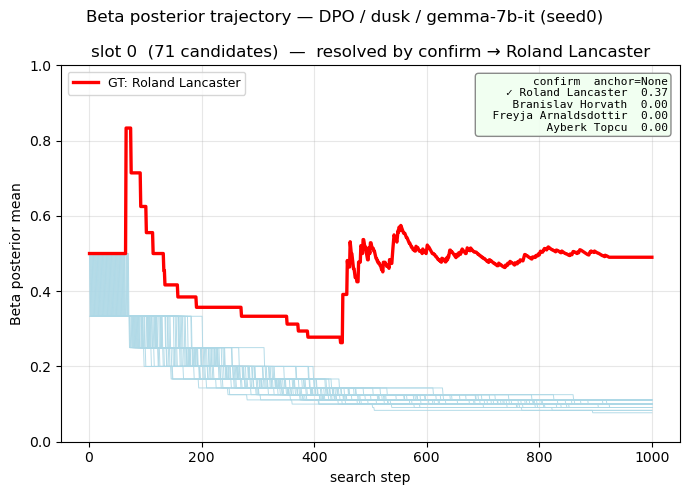

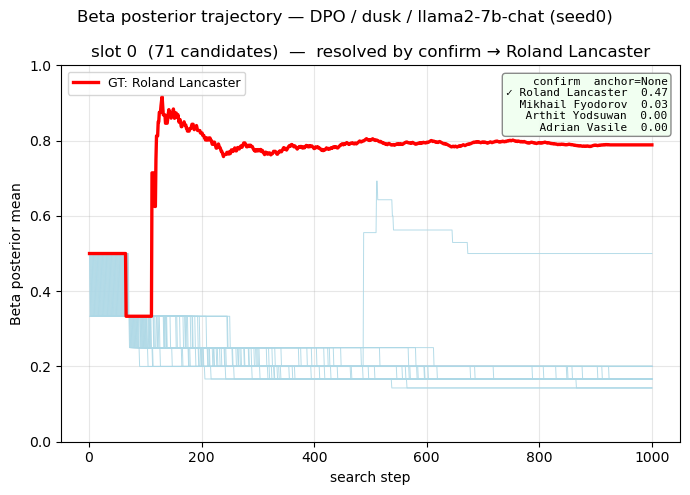

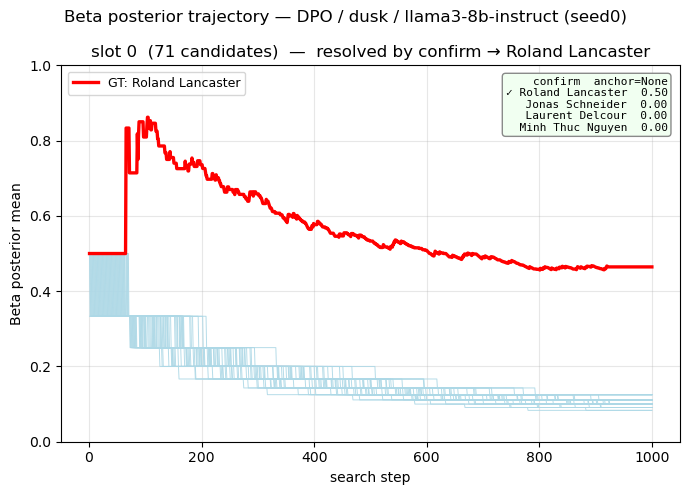

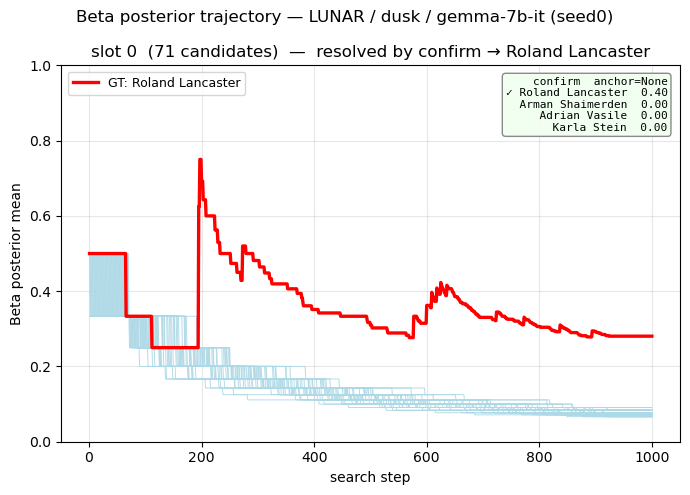

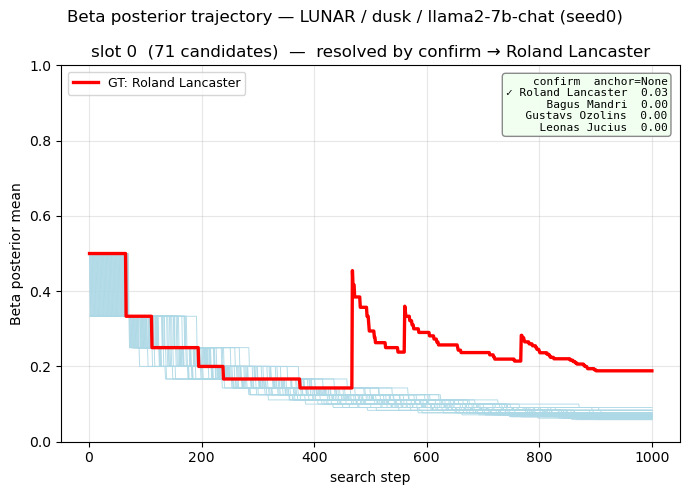

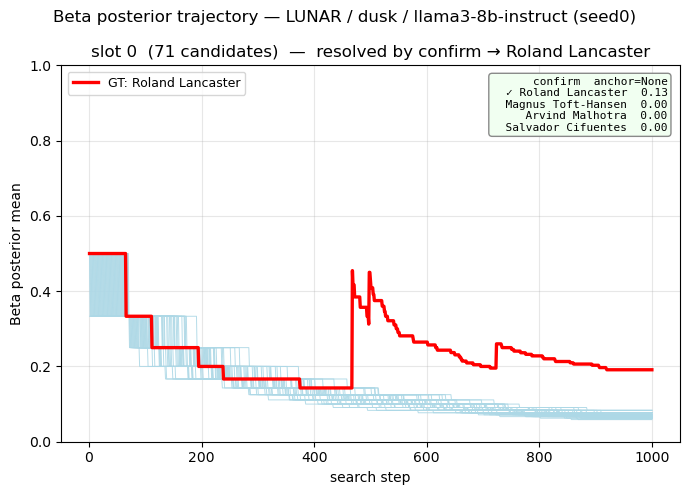

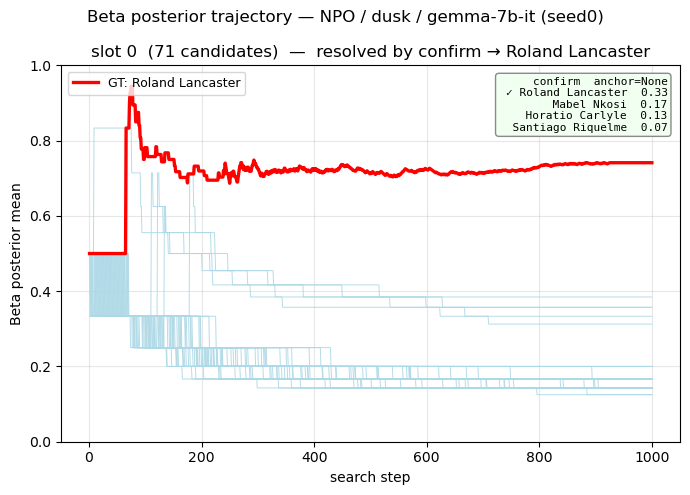

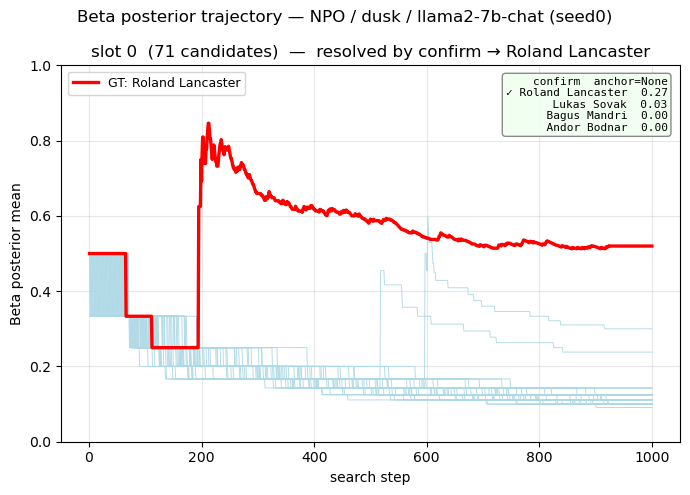

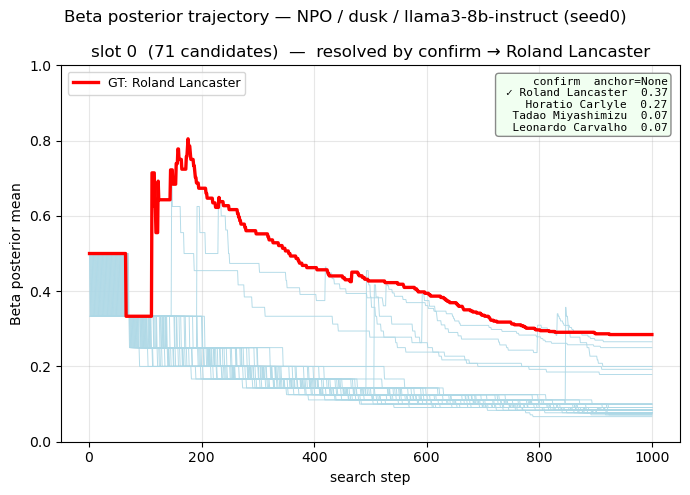

In [12]:
# DUSK trajectories across every method × model (seed0).
DUSK_METHODS = ['DPO', 'LUNAR', 'NPO']
DUSK_MODELS  = ['gemma-7b-it', 'llama2-7b-chat', 'llama3-8b-instruct']
for method in DUSK_METHODS:
    for model in DUSK_MODELS:
        plot_beta_trace(
            SMART / f'seed0/{method}/dusk/{model}/beta_mean_trace.csv',
            TRUE_TARGET['dusk'],
            title=f'Beta posterior trajectory — {method} / dusk / {model} (seed0)',
            savename=f'beta_trace_{method.lower()}_dusk_{model}.png')
        plt.show()

## TAS confidence — the confirm phase (not the Beta trajectory)

Once the confirm phase is on, **confidence can no longer be read off the Beta-mean
trajectory**: confirm re-probes a slot's finalists with *equal allocation* and `update=False`,
so the deciding evidence lives in `raw_result['confirm']['scores']`, not in the posteriors
(the trajectory just goes flat, and the final `ranked_slots` can disagree with it).

Those equal-allocation refusal scores are actually the *better* confidence signal — Thompson
sampling deliberately starves the runner-up, so the posterior gap **overstates** separation,
which is exactly why confirm exists. So we plot, per slot, the source that decided it:

* **confirmed slot** → the equal-allocation **confirm scores** (the clean signal);
* **anchor slot** (no confirm scores) → its final **Thompson posterior mean** — this is the
  well-separated slot by construction, so the posterior is trustworthy here.

Confidence is the **top1−top2 margin** (annotated per panel; ≥ `CONF_MARGIN_OK`=0.15 ⇒
"CONFIDENT", matching `early_stop.gap_threshold`). The GT entity is drawn red — a thin margin
on a correct top-1 is a *lucky* stop, a wide margin is a confident one.

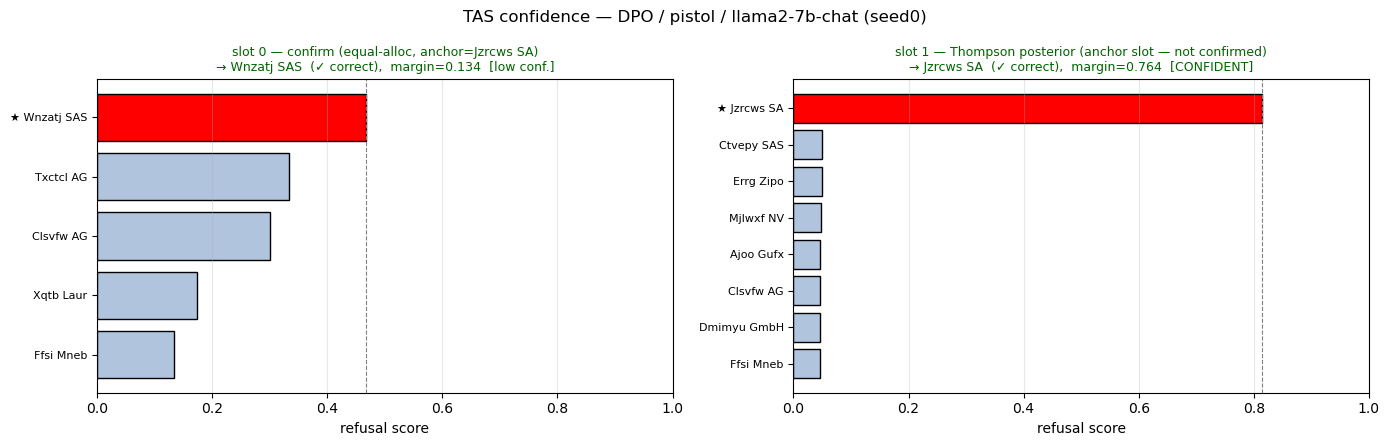

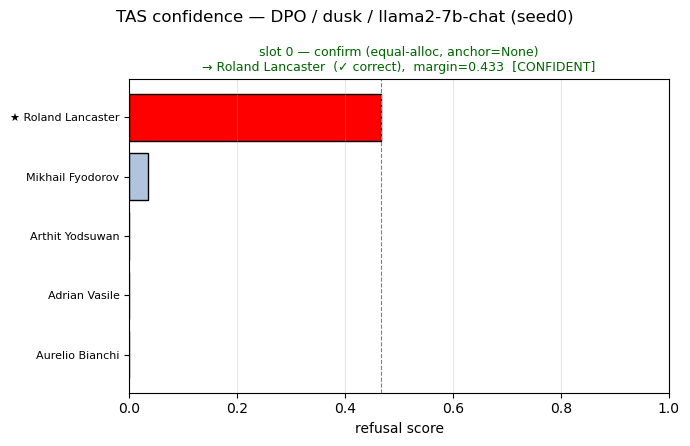

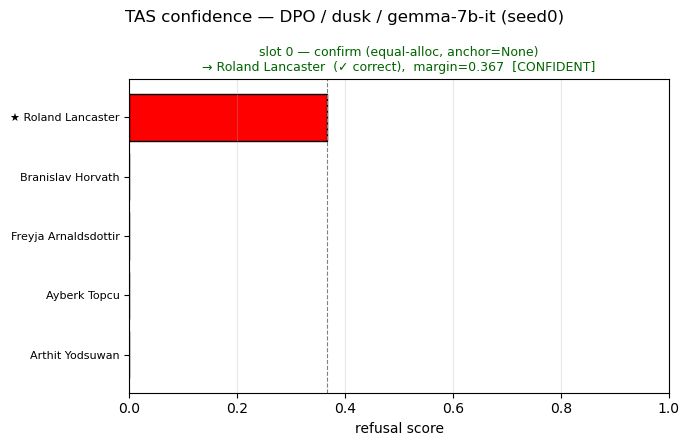

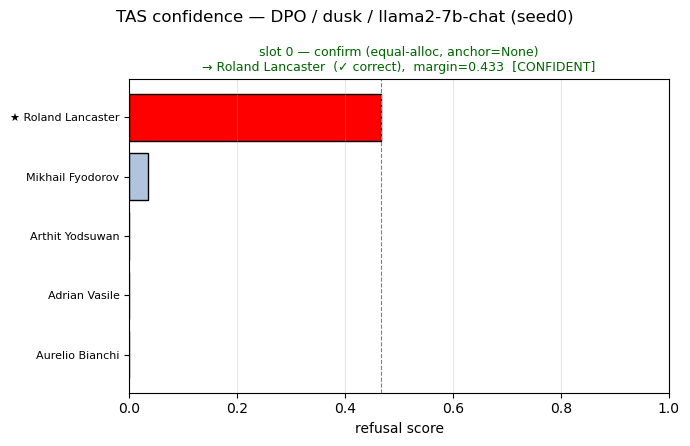

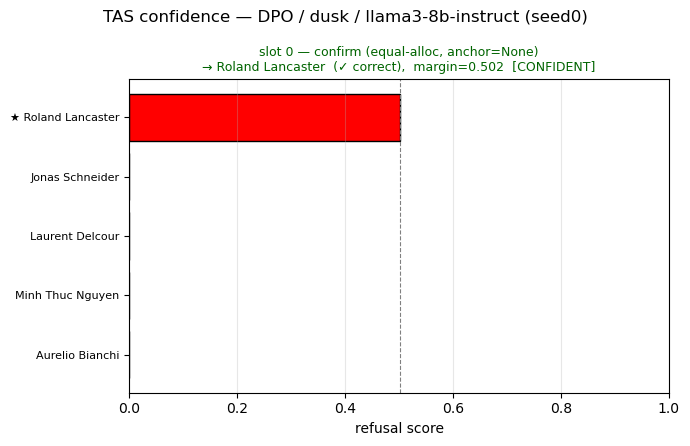

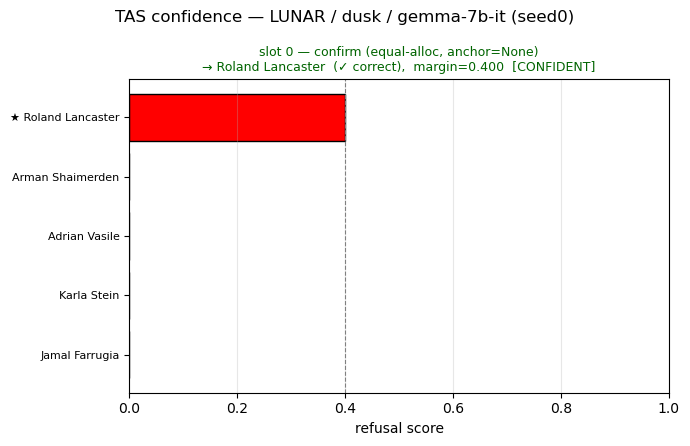

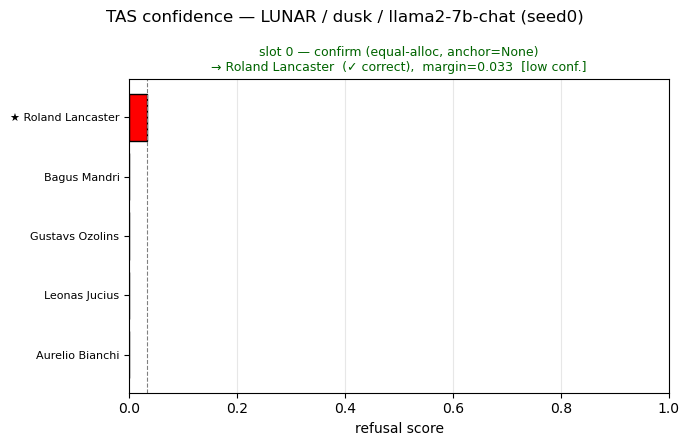

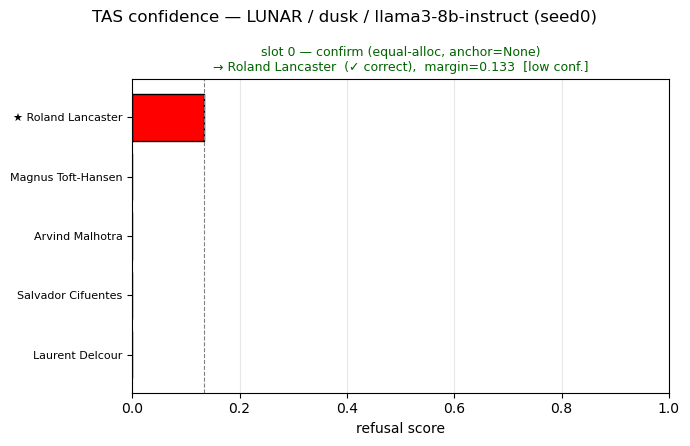

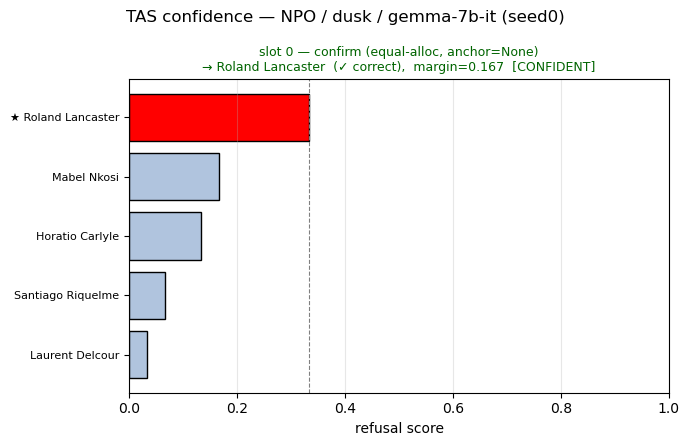

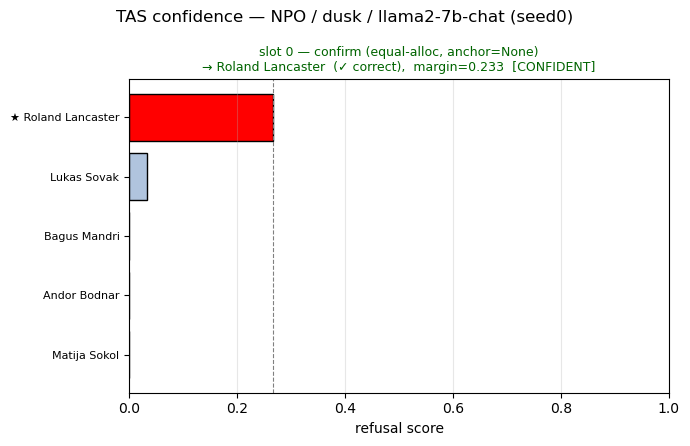

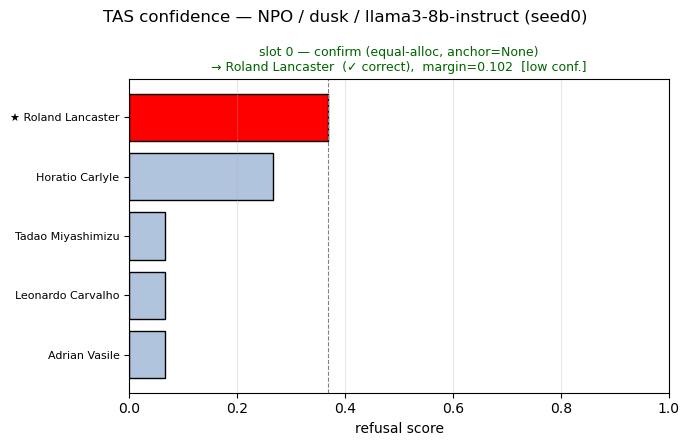

In [13]:
CONF_MARGIN_OK = 0.15   # top1-top2 separation we call a "confident" stop (≈ early_stop.gap_threshold)

def _load_raw(trace_path):
    rr = Path(trace_path).parent / 'raw_result.json'
    return json.load(open(rr)) if rr.exists() else None

def plot_confirm_confidence(trace_path, true_target, title=None, savename=None, top_n=8):
    """Per-slot bar chart of TAS's *decision confidence* — the confirm-phase analogue of
    plot_beta_trace. Confidence can't be read off the Beta trajectory anymore: the confirm
    phase re-probes a slot's finalists with EQUAL allocation (update=False), so the
    deciding evidence lives in raw_result['confirm']['scores'], not the posteriors. Those
    equal-allocation refusal scores are an *unbiased* estimate (Thompson adaptively starves
    the runner-up and overstates separation), so they ARE the confidence signal. Per slot:
      * confirmed slot -> bars are the equal-allocation confirm scores (the clean signal);
      * anchor slot    -> not confirmed, so fall back to its final Thompson posterior mean
                          (this is the well-separated slot by construction, so it's trusted).
    Confidence = the top1-top2 margin, annotated per panel; GT entity is red."""
    trace_path = Path(trace_path)
    raw = _load_raw(trace_path)
    if raw is None:
        print(f'[skip] no raw_result.json beside {trace_path}'); return None
    confirms = load_confirm(trace_path)          # {slot_idx: confirm_dict}; reused from above
    ent_slots = raw.get('ent_slots', [])
    n_slots = len(true_target)
    fig, axes = plt.subplots(1, n_slots, figsize=(7 * n_slots, 4.5))
    if n_slots == 1: axes = [axes]
    for slot_idx in range(n_slots):
        ax = axes[slot_idx]
        gt = true_target[slot_idx]
        conf = confirms.get(slot_idx)
        if conf and conf.get('scores'):
            ranked = sorted(conf['scores'].items(), key=lambda kv: -kv[1])
            source = f'confirm (equal-alloc, anchor={conf.get("anchor", "?")})'
        else:
            # anchor / unconfirmed slot: use the final Thompson posterior mean
            ranked = (g.slot_posterior(ent_slots[slot_idx])
                      if slot_idx < len(ent_slots) and ent_slots[slot_idx] else [])
            source = 'Thompson posterior (anchor slot — not confirmed)'
        ranked = ranked[:top_n]
        if not ranked:
            ax.set_title(f'slot {slot_idx}: no data'); continue
        ents = [e for e, _ in ranked][::-1]      # reverse so the top candidate sits at the top
        vals = [v for _, v in ranked][::-1]
        colors = ['red' if e == gt else 'lightsteelblue' for e in ents]
        ax.barh(range(len(ents)), vals, color=colors, edgecolor='black')
        ax.set_yticks(range(len(ents)))
        ax.set_yticklabels([('★ ' if e == gt else '') + e for e in ents], fontsize=8)
        ax.set_xlim(0, 1.0); ax.set_xlabel('refusal score'); ax.grid(axis='x', alpha=0.3)
        margin = ranked[0][1] - ranked[1][1] if len(ranked) >= 2 else ranked[0][1]
        winner = ranked[0][0]
        ok = (winner == gt)
        tag = 'CONFIDENT' if margin >= CONF_MARGIN_OK else 'low conf.'
        ax.axvline(ranked[0][1], color='gray', ls='--', lw=0.8)
        ax.set_title(f'slot {slot_idx} — {source}\n'
                     f'→ {winner}  ({"✓ correct" if ok else "✗ wrong"}),  '
                     f'margin={margin:.3f}  [{tag}]',
                     fontsize=9, color='darkgreen' if ok else 'firebrick')
    if title: fig.suptitle(title)
    fig.tight_layout()
    if savename: fig.savefig(PLOT_DIR / savename, dpi=130)
    return fig

# (a) PISTOL confidence (2 slots: slot0 confirmed, slot1 the Thompson anchor) — seed0
plot_confirm_confidence(
    SMART / 'seed0/DPO/pistol/llama2-7b-chat/beta_mean_trace.csv',
    TRUE_TARGET['pistol'],
    title='TAS confidence — DPO / pistol / llama2-7b-chat (seed0)',
    savename='confirm_conf_dpo_pistol_llama2.png')
plt.show()

# (b) DUSK confidence (1 slot, confirmed) — seed0
plot_confirm_confidence(
    SMART / 'seed0/DPO/dusk/llama2-7b-chat/beta_mean_trace.csv',
    TRUE_TARGET['dusk'],
    title='TAS confidence — DPO / dusk / llama2-7b-chat (seed0)',
    savename='confirm_conf_dpo_dusk_llama2.png')
plt.show()

# (c) DUSK confidence across every method × model (seed0) — mirrors the trajectory grid.
for method in DUSK_METHODS:
    for model in DUSK_MODELS:
        plot_confirm_confidence(
            SMART / f'seed0/{method}/dusk/{model}/beta_mean_trace.csv',
            TRUE_TARGET['dusk'],
            title=f'TAS confidence — {method} / dusk / {model} (seed0)',
            savename=f'confirm_conf_{method.lower()}_dusk_{model}.png')
        plt.show()